In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay)
import pickle
from joblib import dump
import os

In [22]:
df_engineered_train = pd.read_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/processed/engineered_train.csv")
df_engineered_test = pd.read_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/processed/engineered_test.csv")

In [23]:
#instantiate and fit the model

model = LogisticRegression(max_iter = 1000)
X_train = df_engineered_train.drop(columns=["default_flag"])
y_train = df_engineered_train["default_flag"]
X_test = df_engineered_test.drop(columns=["default_flag"])
y_test = df_engineered_test["default_flag"]
model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)  
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7867


c:\Users\mutch_lf652j0\anaconda3\envs\creditriskmodel\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
gini = 2 * auc_score - 1
print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.5733


In [25]:
threshold = 0.3
y_pred = (y_probs >= threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     30523
           1       0.45      0.43      0.44      5561

    accuracy                           0.83     36084
   macro avg       0.67      0.67      0.67     36084
weighted avg       0.83      0.83      0.83     36084



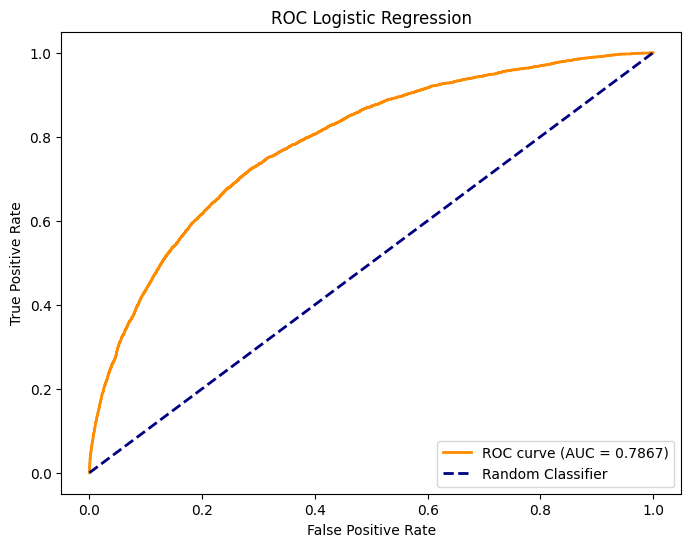

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr, color = 'darkorange', lw = 2, label = f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Logistic Regression')
plt.legend(loc = 'lower right')
plt.show()

<Figure size 800x600 with 0 Axes>

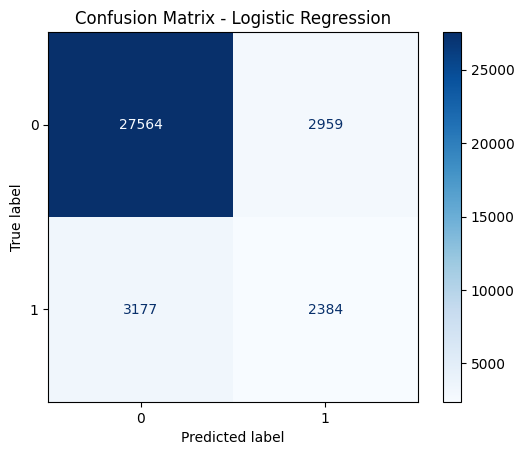

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [31]:
model_path = "C:/Users/mutch_lf652j0/Credit Score Interactive Model/models/logistic_regression.pkl"
dump(model, model_path)
print("Saved successfully")
print(type(model))

Saved successfully
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [29]:
X_train.columns.tolist()

['age',
 'employment_length_years',
 'num_open_accounts',
 'credit_utilisation_pct',
 'interest_rate',
 'months_since_last_delinquency',
 'pct_accounts_current',
 'missing_annual_income',
 'missing_months_since_last_delinquency',
 'credit_history_to_age',
 'hard_inquiries_delinquencies',
 'rate_dti_burden',
 'rate_to_age',
 'log_annual_income',
 'log_loan_amount',
 'log_total_revolving_balance',
 'log_interest_to_income',
 'log_num_hard_inquiries_6mo',
 'log_num_delinquencies_2yr']

In [30]:
print(type(model))
print(model.coef_)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
[[-0.03001879 -0.04414151  0.0689919   0.01447528 -0.01559566 -0.00123333
   0.00085994  0.42252     0.26142465 -0.29622236 -0.20522599  0.08614156
   0.61263347 -0.17046183 -0.22684141 -0.0274151   0.85968332  0.75597512
   0.78363474]]
